In [8]:
%pip install --upgrade --quiet torch pandas numpy matplotlib scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from datetime import datetime
import seaborn as sns


### Data Preparation

In [10]:
data = pd.read_csv('rnn_data.csv')

In [11]:
data.head()

,pitch_type,game_date,batter,pitcher,description,zone,stand,p_throws,balls,strikes,...,is_whiff,is_called_strike,is_ball,in_zone,out_zone,count_state,score_diff_bat,pa_id,prev_pitch_type,seq_len
0,FF,2025-03-18,660271,684007,called_strike,12.0,L,L,0,0,...,False,True,False,False,True,0-0,0,778563_1,START,3
1,SL,2025-03-18,660271,684007,ball,13.0,L,L,0,1,...,False,False,True,False,True,0-1,0,778563_1,FF,3
2,FF,2025-03-18,660271,684007,hit_into_play,5.0,L,L,1,1,...,False,False,False,True,False,1-1,0,778563_1,SL,3
3,FS,2025-03-18,669242,684007,ball,13.0,R,L,0,0,...,False,False,True,False,True,0-0,0,778563_2,START,3
4,FS,2025-03-18,669242,684007,swinging_strike,14.0,R,L,1,0,...,True,False,False,False,True,1-0,0,778563_2,FS,3


In [12]:
data["is_real_pitch"] =  data["pitch_type"].notna() & (data["pitch_type"] != "ABS")

data["target_is_real_pitch"] = data.groupby("pa_id")["is_real_pitch"].shift(-1)

data["y_next_pitch_type"] = data.groupby("pa_id")["pitch_type"].shift(-1)

data_train = data[data["target_is_real_pitch"] == True].copy() 

In [13]:
# randomly select plate appearances to be a part of training and test sets

def split_by_pa_id(df: pd.DataFrame, pa_col="pa_id", ratios=(0.8, 0.2), seed: int=42):
    r_train, r_test = ratios
    assert abs((r_train + r_test) - 1.0) < 1e-9

    pa_ids = df[pa_col].dropna().unique()

    rng = np.random.default_rng(seed)
    rng.shuffle(pa_ids)

    n = len(pa_ids)
    n_train = int(n*r_train)

    train_ids = set(pa_ids[:n_train])
    test_ids = set(pa_ids[n_train:])

    train_df = df[df[pa_col].isin(train_ids)].copy()
    test_df = df[df[pa_col].isin(test_ids)].copy()

    return train_df, test_df, train_ids, test_ids

In [14]:
train_df, test_df, train_ids, test_ids = split_by_pa_id(
    data_train, pa_col="pa_id", ratios=(0.8, 0.2), seed=7
)

C:\Users\sethb\AppData\Local\Temp\ipykernel_31780\1463695035.py:10: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng.shuffle(pa_ids)


In [15]:
# Features to be used by the model
FEATURE_SPEC = {
    "target": "y_next_pitch_type",
    "cat_cols": [
        "pitcher", "batter", "stand", "p_throws", "inning_topbot",
        "count_state", "prev_pitch_type"
    ],
    "num_cols": [
        "balls", "strikes", "outs_when_up", "inning", "score_diff_bat",
        "on_1b", "on_2b", "on_3b"
    ],
}

TARGET_COL = FEATURE_SPEC["target"]
CAT_COLS = FEATURE_SPEC["cat_cols"]
NUM_COLS = FEATURE_SPEC["num_cols"]

In [16]:
PAD_ID = 0

def build_vocab(values):
    uniq = pd.Series(values.dropna().unique())
    return {v: i for i, v in enumerate(uniq, start=1)}

def encode(series, vocab):
    return series.map(vocab).fillna(PAD_ID).astype(int)

cat_vocabs = {c: build_vocab(train_df[c]) for c in CAT_COLS}
y_vocab    = build_vocab(train_df[TARGET_COL])
cat_vocab_sizes = {c: len(cat_vocabs[c]) + 1 for c in CAT_COLS}  
num_classes = len(y_vocab) + 1   

scaler = StandardScaler()
scaler.fit(train_df[NUM_COLS].fillna(0))

def encode_df(df):
    out = df.copy()
    for c in CAT_COLS:
        out[c + "_id"] = encode(out[c], cat_vocabs[c])
    out["y_id"] = encode(out[TARGET_COL], y_vocab)
    for c in NUM_COLS:
        out[c] = pd.to_numeric(out[c], errors="coerce").fillna(0).astype(np.float32)

    out[NUM_COLS] = scaler.transform(out[NUM_COLS])
    return out

train_enc = encode_df(train_df)
test_enc  = encode_df(test_df)

In [17]:
# make all pitch sequences the same length
def make_fixed_sequences(df, pa_col="pa_id", max_len=8):
    X_cat, X_num, Y = [], [], []

    for _, g in df.groupby(pa_col, sort=False):

        cat = g[[c + "_id" for c in CAT_COLS]].to_numpy(np.int64)     
        num = g[NUM_COLS].to_numpy(np.float32)                        
        y   = g["y_id"].to_numpy(np.int64)                            

        L = min(len(g), max_len)
        cat, num, y = cat[:L], num[:L], y[:L]

        pad = max_len - L
        if pad > 0:
            cat = np.pad(cat, ((0,pad),(0,0)), constant_values=PAD_ID)
            num = np.pad(num, ((0,pad),(0,0)), constant_values=0.0)
            y   = np.pad(y,   (0,pad),         constant_values=PAD_ID)

        X_cat.append(cat); X_num.append(num); Y.append(y)

    return (
        torch.tensor(np.stack(X_cat), dtype=torch.long),
        torch.tensor(np.stack(X_num), dtype=torch.float32),
        torch.tensor(np.stack(Y),     dtype=torch.long),
    )

MAX_LEN = 8
Xc_tr, Xn_tr, Y_tr = make_fixed_sequences(train_enc, max_len=MAX_LEN)
Xc_te, Xn_te, Y_te = make_fixed_sequences(test_enc,  max_len=MAX_LEN)

In [18]:
# Create the Dataset
class PitchSeqDS(Dataset):
    def __init__(self, Xc, Xn, Y):
        self.Xc, self.Xn, self.Y = Xc, Xn, Y
    def __len__(self): return self.Y.size(0)
    def __getitem__(self, i): return self.Xc[i], self.Xn[i], self.Y[i]

train_loader = DataLoader(PitchSeqDS(Xc_tr, Xn_tr, Y_tr), batch_size=64, shuffle=True)
test_loader  = DataLoader(PitchSeqDS(Xc_te, Xn_te, Y_te), batch_size=64, shuffle=False)

In [19]:
from datetime import datetime
from pathlib import Path
import pandas as pd

# Export vocabularies and feature lists with a date-stamped filename.
today = datetime.now().strftime("%Y%m%d")
repo_root = Path.cwd().parent
vocab_dir = repo_root / "model_shared" / "vocab"
feature_dir = repo_root / "model_shared" / "feature-list"
vocab_dir.mkdir(parents=True, exist_ok=True)
feature_dir.mkdir(parents=True, exist_ok=True)

rows = []
for feature, vocab in cat_vocabs.items():
    for value, idx in vocab.items():
        rows.append({"feature": feature, "value": value, "id": idx, "kind": "categorical"})
for value, idx in y_vocab.items():
    rows.append({"feature": TARGET_COL, "value": value, "id": idx, "kind": "target"})

vocab_path = vocab_dir / f"rnn_vocab_{today}.csv"
pd.DataFrame(rows).to_csv(vocab_path, index=False)

feature_rows = []
for c in CAT_COLS:
    feature_rows.append({"feature": c, "kind": "categorical"})
for c in NUM_COLS:
    feature_rows.append({"feature": c, "kind": "numerical"})
feature_rows.append({"feature": TARGET_COL, "kind": "target"})

feature_path = feature_dir / f"rnn_vocab_{today}.csv"
pd.DataFrame(feature_rows).to_csv(feature_path, index=False)

print(f"Wrote vocab to {vocab_path}")
print(f"Wrote feature list to {feature_path}")


Wrote vocab to c:\Users\sethb\Baseball\pitchcraft-model\model_shared\vocab\rnn_vocab_20260214.csv
Wrote feature list to c:\Users\sethb\Baseball\pitchcraft-model\model_shared\feature-list\rnn_vocab_20260214.csv


### Model Definitions

In [20]:
# Model Simple RNN Model
class SimplePitchRNN(nn.Module):
    def __init__(self, cat_vocab_sizes, num_features, emb_dims=None, hidden=128, num_classes=16, pad_id=0):
        super().__init__()
        self.cat_cols = list(cat_vocab_sizes.keys())

        if emb_dims is None:
            emb_dims = {col: 16 for col in self.cat_cols}

        self.embs = nn.ModuleDict({
            col: nn.Embedding(cat_vocab_sizes[col], emb_dims[col], padding_idx=pad_id)
            for col in self.cat_cols
        })
        
        in_dim = sum(emb_dims.values())+ num_features
        self.rnn = nn.RNN(in_dim, hidden, batch_first=True)
        self.fc  = nn.Linear(hidden, num_classes)

    def forward(self, x_cat, x_num):
        embs = []
        for j, col in enumerate(self.cat_cols):
            embs.append(self.embs[col](x_cat[:, :, j]))  
        x = torch.cat(embs + [x_num], dim=-1)           
        h, _ = self.rnn(x)                               
        return self.fc(h)                                                                

In [21]:
# Model with Dropout
class PitchRNNWithDropout(nn.Module):
    def __init__(self, cat_vocab_sizes, num_features, emb_dim=16, hidden=128, num_classes=16, pad_id=0, dropout=0.3):
        super().__init__()
        self.cat_cols = list(cat_vocab_sizes.keys())

        self.embs = nn.ModuleDict({
            col: nn.Embedding(cat_vocab_sizes[col], emb_dim, padding_idx=pad_id)
            for col in self.cat_cols
        })

        self.emb_dropout = nn.Dropout(dropout)
        
        in_dim = len(self.cat_cols) * emb_dim + num_features
        self.rnn = nn.RNN(in_dim, hidden, batch_first=True, dropout=dropout if dropout > 0 else 0)
        self.fc_dropout = nn.Dropout(dropout)
        self.fc  = nn.Linear(hidden, num_classes)

    def forward(self, x_cat, x_num):
        embs = []
        for j, col in enumerate(self.cat_cols):
            embs.append(self.embs[col](x_cat[:, :, j]))  

        embs = [self.emb_dropout(emb) for emb in embs]

        x = torch.cat(embs + [x_num], dim=-1)           
        h, _ = self.rnn(x)        
        h = self.fc_dropout(h)                       
        return self.fc(h)                            

### Model improvements

In [22]:
# Calculating Class Weights 
def calculate_class_weights(y_train, pad_id=0, smoothing=0.2):
    y_flat = y_train.flatten()
    y_flat = y_flat[y_flat != pad_id]

    unique, counts = np.unique(y_flat, return_counts=True)

    total = len(y_flat)
    frequencies = counts / total
    weights = (1.0 / frequencies) ** smoothing

    weight_tensor = torch.zeros(num_classes)
    for class_id, weight in zip (unique, weights):
        weight_tensor[class_id] = weight
    return weight_tensor

class_weights = calculate_class_weights(Y_tr)
class_weights

tensor([0.0000, 1.4619, 1.2596, 1.9154, 1.4753, 1.6947, 1.7173, 2.2490, 1.6944,
        1.5371, 3.8652, 2.8790, 4.2934, 3.8620, 4.0726])

In [23]:
# Creating a class to track early stopping
class EarlyStopping: 
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_score = None
        self.early_stop = False 
        self.counter = 0 
        self.best_model_state = None 

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.best_model_state = model.state_dict()
        elif score < self.best_score + self.delta:
            self.counter += 1 
            if self.counter >= self.patience:
                self.early_stop = True
        else: 
            self.best_score = score 
            self.best_model_state = model.state_dict()
            self.counter = 0

    def load_best_model(self, model):
        model.load_state_dict(self.best_model_state)

### Training Functions

In [24]:
# Simplified the training loop
def train_with_weights(model, criterion, optimizer, device):
    epochs = 20
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for x_cat, x_num, y in train_loader:
            x_cat = x_cat.to(device)
            x_num = x_num.to(device)
            y     = y.to(device)
            logits = model(x_cat, x_num)  

            loss = criterion(
                logits.reshape(-1, num_classes),
                y.reshape(-1)
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss / len(train_loader):.4f}')

In [25]:
def train_with_early_stopping(model, train_loader, test_loader, criterion, optimizer, early_stopping, device):
    epochs = 20
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for x_cat, x_num, y in train_loader:
            x_cat = x_cat.to(device)
            x_num = x_num.to(device)
            y     = y.to(device)
            logits = model(x_cat, x_num)  

            loss = criterion(
                logits.reshape(-1, num_classes),
                y.reshape(-1)
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x_cat.size(0)
        
        train_loss /= len(train_loader.dataset)

        model.eval()
        test_loss = 0
        with torch.no_grad():
            for x_cat, x_num, y in test_loader:
                x_cat = x_cat.to(device)
                x_num = x_num.to(device)
                y     = y.to(device)

                logits = model(x_cat, x_num)  
                loss = criterion(
                    logits.reshape(-1, num_classes),
                    y.reshape(-1)
                )
                test_loss += loss.item() * x_cat.size(0)
            
        test_loss /= len(test_loader.dataset)

        print(f'Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')

        early_stopping(test_loss, model)
        if early_stopping.early_stop:
            print("Early Stopping")
            break

    early_stopping.load_best_model(model)
    

### Execute Training

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_model = SimplePitchRNN(cat_vocab_sizes, num_features=len(NUM_COLS), num_classes=num_classes)
weights_model = weights_model.to(device)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, weight=class_weights)
optimizer = optim.Adam(weights_model.parameters(), lr=0.001)

train_with_weights(weights_model, criterion, optimizer, device)

Epoch [1/20], Loss: 1.7441
Epoch [2/20], Loss: 1.4907
Epoch [3/20], Loss: 1.3957
Epoch [4/20], Loss: 1.3506
Epoch [5/20], Loss: 1.3224
Epoch [6/20], Loss: 1.3048
Epoch [7/20], Loss: 1.2918
Epoch [8/20], Loss: 1.2819
Epoch [9/20], Loss: 1.2734
Epoch [10/20], Loss: 1.2668
Epoch [11/20], Loss: 1.2605
Epoch [12/20], Loss: 1.2550
Epoch [13/20], Loss: 1.2505
Epoch [14/20], Loss: 1.2459
Epoch [15/20], Loss: 1.2416
Epoch [16/20], Loss: 1.2374
Epoch [17/20], Loss: 1.2337
Epoch [18/20], Loss: 1.2306
Epoch [19/20], Loss: 1.2266
Epoch [20/20], Loss: 1.2237


In [27]:
early_stopping_model = SimplePitchRNN(cat_vocab_sizes, num_features=len(NUM_COLS), num_classes=num_classes)
early_stopping_model = early_stopping_model.to(device)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
optimizer = optim.Adam(early_stopping_model.parameters(), lr=0.001)
early_stopping = EarlyStopping(patience=5, delta=0.01)

train_with_early_stopping(early_stopping_model, train_loader, test_loader, criterion, optimizer, early_stopping, device)

Epoch 1, Train Loss: 1.6888, Test Loss: 1.5372
Epoch 2, Train Loss: 1.4554, Test Loss: 1.4050
Epoch 3, Train Loss: 1.3641, Test Loss: 1.3514
Epoch 4, Train Loss: 1.3221, Test Loss: 1.3251
Epoch 5, Train Loss: 1.2978, Test Loss: 1.3146
Epoch 6, Train Loss: 1.2818, Test Loss: 1.3018
Epoch 7, Train Loss: 1.2707, Test Loss: 1.2988
Epoch 8, Train Loss: 1.2619, Test Loss: 1.2926
Epoch 9, Train Loss: 1.2544, Test Loss: 1.2883
Epoch 10, Train Loss: 1.2483, Test Loss: 1.2890
Epoch 11, Train Loss: 1.2428, Test Loss: 1.2920
Epoch 12, Train Loss: 1.2375, Test Loss: 1.2846
Epoch 13, Train Loss: 1.2337, Test Loss: 1.2839
Epoch 14, Train Loss: 1.2293, Test Loss: 1.2842
Early Stopping


In [28]:
dropout_model = PitchRNNWithDropout(
    cat_vocab_sizes, 
    num_features=len(NUM_COLS), 
    num_classes=num_classes,
    dropout=0.1  
)
dropout_model = dropout_model.to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, weight=class_weights)
optimizer = optim.Adam(dropout_model.parameters(), lr=0.001)
early_stopping = EarlyStopping(patience=5, delta=0.01)

train_with_early_stopping(dropout_model, train_loader, test_loader, 
                          criterion, optimizer, early_stopping, device)

c:\Users\sethb\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\torch\nn\modules\rnn.py:641: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__(mode, *args, **kwargs)


Epoch 1, Train Loss: 1.7842, Test Loss: 1.5957
Epoch 2, Train Loss: 1.5532, Test Loss: 1.4633
Epoch 3, Train Loss: 1.4621, Test Loss: 1.3995
Epoch 4, Train Loss: 1.4149, Test Loss: 1.3705
Epoch 5, Train Loss: 1.3883, Test Loss: 1.3491
Epoch 6, Train Loss: 1.3688, Test Loss: 1.3356
Epoch 7, Train Loss: 1.3550, Test Loss: 1.3272
Epoch 8, Train Loss: 1.3454, Test Loss: 1.3183
Epoch 9, Train Loss: 1.3362, Test Loss: 1.3129
Epoch 10, Train Loss: 1.3298, Test Loss: 1.3100
Epoch 11, Train Loss: 1.3252, Test Loss: 1.3069
Epoch 12, Train Loss: 1.3192, Test Loss: 1.3043
Epoch 13, Train Loss: 1.3160, Test Loss: 1.3010
Epoch 14, Train Loss: 1.3122, Test Loss: 1.3049
Epoch 15, Train Loss: 1.3088, Test Loss: 1.3010
Epoch 16, Train Loss: 1.3063, Test Loss: 1.2991
Early Stopping


In [29]:
custom_emb_dims = {
    "pitcher": 32,  
    "batter": 32,      
    "stand": 2,      
    "p_throws": 2,
    "inning_topbot": 2,
    "count_state": 12,
    "prev_pitch_type": 16
}

emb_model = SimplePitchRNN(
    cat_vocab_sizes=cat_vocab_sizes,
    num_features=len(NUM_COLS),
    emb_dims=custom_emb_dims,
    num_classes=num_classes
)

emb_model = emb_model.to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, weight=class_weights)
optimizer = optim.Adam(emb_model.parameters(), lr=0.001)
early_stopping = EarlyStopping(patience=5, delta=0.01)

train_with_early_stopping(emb_model, train_loader, test_loader, 
                          criterion, optimizer, early_stopping, device)

Epoch 1, Train Loss: 1.6847, Test Loss: 1.4878
Epoch 2, Train Loss: 1.4083, Test Loss: 1.3729
Epoch 3, Train Loss: 1.3372, Test Loss: 1.3399
Epoch 4, Train Loss: 1.3059, Test Loss: 1.3207
Epoch 5, Train Loss: 1.2873, Test Loss: 1.3158
Epoch 6, Train Loss: 1.2743, Test Loss: 1.3110
Epoch 7, Train Loss: 1.2641, Test Loss: 1.3050
Epoch 8, Train Loss: 1.2553, Test Loss: 1.3084
Epoch 9, Train Loss: 1.2476, Test Loss: 1.3051
Epoch 10, Train Loss: 1.2411, Test Loss: 1.3064
Epoch 11, Train Loss: 1.2349, Test Loss: 1.3083
Epoch 12, Train Loss: 1.2288, Test Loss: 1.3105
Early Stopping


In [30]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from collections import Counter

def get_all_predictions(model, test_loader, device, pad_id = 0):
    model.eval()
    all_preds = [] 
    all_true = []

    with torch.no_grad():
        for x_cat, x_num, y in test_loader:
            x_cat = x_cat.to(device)
            x_num = x_num.to(device)
            y = y.to(device)
            logits = model(x_cat, x_num)        # (B, L, C)
            preds  = logits.argmax(dim=-1)      # (B, L)

            mask = (y != pad_id)

            valid = mask.bool()

            all_preds.append(preds[valid].cpu().numpy())
            all_true.append(y[valid].cpu().numpy())
    
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_true)

    return y_true, y_pred

def print_classification_report(model, test_loader, device, id_to_pitch, pad_id=0):
    y_true, y_pred = get_all_predictions(model, test_loader, device, pad_id)
    target_names = list(id_to_pitch.values())
    report = classification_report(y_true, y_pred, target_names=target_names)
    print(report)
    return report

def get_strategic_accuracy(model, test_loader, device, id_to_pitch, pad_id=0):
    y_true, y_pred = get_all_predictions(model, test_loader, device, pad_id)
    
    fastballs = {'FF', 'SI', 'FC'}
    breaking = {'SL', 'CU', 'KC', 'SV', 'ST'}
    offspeed = {'CH', 'FS'}
    
    def pitch_to_family(pitch):
        if pitch in fastballs: return 'fastball'
        if pitch in breaking: return 'breaking'
        if pitch in offspeed: return 'offspeed'
        return 'other'
    
    y_true_family = [pitch_to_family(id_to_pitch[y]) for y in y_true]
    y_pred_family = [pitch_to_family(id_to_pitch[p]) for p in y_pred]
    
    report = classification_report(y_true_family, y_pred_family)
    print(report)
    return report

def generate_confusion_matrix(model, test_loader, device, pad_id=0, figsize=(12, 10)):
    """Generate and display confusion matrix."""
    y_true, y_pred = get_all_predictions(model, test_loader, device, pad_id)
    
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    
    plt.figure(figsize=figsize)
    sns.heatmap(cm_norm, cmap="Blues", fmt="d")
    plt.xlabel("Predicted Pitch Type")
    plt.ylabel("True Pitch Type")
    plt.title("Pitch Type Confusion Matrix (Token-Level)")
    plt.show()
    
    return cm, cm_norm

def get_accuracy(model, test_loader, device, pad_id=0):
    y_true, y_pred = get_all_predictions(model, test_loader, device, pad_id)
    correct = (y_pred == y_true).sum()
    total = len(y_true)
    accuracy = 100 * correct / total
    print(f"Token Accuracy (no PAD): {accuracy:.2f}%")
    return accuracy

def get_top_k_accuracy(model, test_loader, device, K=3, pad_id=0):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for x_cat, x_num, y in test_loader:
            x_cat = x_cat.to(device)
            x_num = x_num.to(device)
            y = y.to(device)
            
            logits = model(x_cat, x_num)
            topk = logits.topk(K, dim=-1).indices
            mask = (y != pad_id)
            match = (topk == y.unsqueeze(-1)).any(dim=-1)
            correct += (match & mask).sum().item()
            total += mask.sum().item()
    
    accuracy = 100 * correct / total
    print(f"Top-{K} Accuracy: {accuracy:.2f}%")
    return accuracy

def get_most_common_pitches(model, test_loader, device, id_to_pitch, top_n=5, pad_id=0):
    model.eval()
    counts = Counter()
    
    with torch.no_grad():
        for x_cat, x_num, y in test_loader:
            x_cat = x_cat.to(device)
            x_num = x_num.to(device)
            preds = model(x_cat, x_num).argmax(dim=-1)
            for p in preds.view(-1).tolist():
                if p != pad_id:
                    counts[p] += 1
    
    print(f"Top {top_n} most predicted pitches:")
    for pid, cnt in counts.most_common(top_n):
        print(f"  {id_to_pitch.get(pid, 'PAD')}: {cnt}")
    
    return counts.most_common(top_n)

In [31]:
def evaluate_model_complete(model, test_loader, device, id_to_pitch, num_classes, pad_id=0):
    
    print("\n1. Token Accuracy:")
    acc = get_accuracy(model, test_loader, device, pad_id)
    
    print("\n2. Top-3 Accuracy:")
    top3 = get_top_k_accuracy(model, test_loader, device, K=3, pad_id=pad_id)
    
    print("\n3. Most Common Predictions:")
    common = get_most_common_pitches(model, test_loader, device, id_to_pitch, pad_id=pad_id)
    
    print("\n4. Detailed Classification Report:")
    class_report = print_classification_report(model, test_loader, device, id_to_pitch, pad_id)
    
    print("\n5. Strategic Accuracy (by pitch family):")
    strat_report = get_strategic_accuracy(model, test_loader, device, id_to_pitch, pad_id)
    
    print("\n6. Confusion Matrix:")
    cm, cm_norm = generate_confusion_matrix(model, test_loader, device, pad_id)
    
    return {
        'accuracy': acc,
        'top3_accuracy': top3,
        'most_common': common,
        'classification_report': class_report,
        'strategic_report': strat_report,
        'confusion_matrix': cm,
        'confusion_matrix_normalized': cm_norm
    }


1. Token Accuracy:
Token Accuracy (no PAD): 42.11%

2. Top-3 Accuracy:
Top-3 Accuracy: 87.37%

3. Most Common Predictions:
Top 5 most predicted pitches:
  SL: 57958
  FF: 54108
  SI: 43953
  CH: 28291
  ST: 25980

4. Detailed Classification Report:
              precision    recall  f1-score   support

          SL       0.43      0.45      0.44     15820
          FF       0.51      0.44      0.47     33475
          FS       0.40      0.48      0.44      3889
          SI       0.44      0.40      0.42     15342
          ST       0.36      0.49      0.42      7596
          CU       0.33      0.29      0.31      7114
          KC       0.34      0.50      0.41      1781
          FC       0.32      0.41      0.36      7658
          CH       0.39      0.34      0.36     12150
          FA       0.76      0.70      0.73       142
          SV       0.26      0.68      0.37       530
       OTHER       0.28      0.38      0.32        71
          EP       0.71      0.74      0.72    

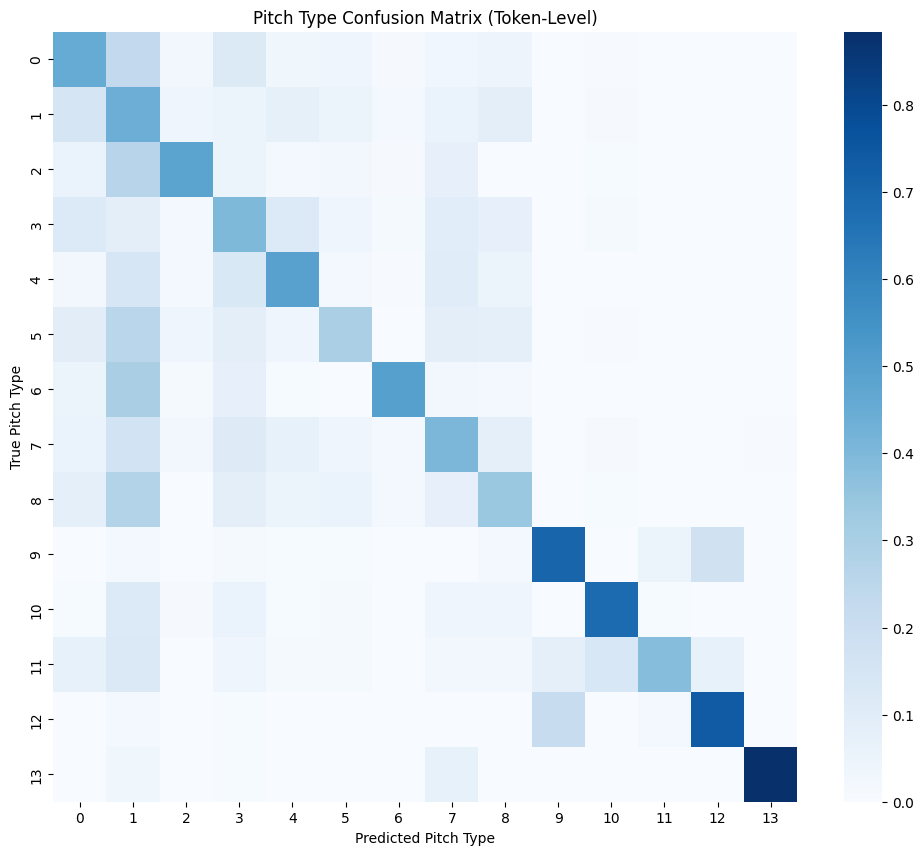

In [32]:
id_to_pitch = {v: k for k, v in y_vocab.items()}

weights_results = evaluate_model_complete(
    model=weights_model,
    test_loader=test_loader,
    device=device,
    id_to_pitch=id_to_pitch,
    num_classes=num_classes,
    pad_id=PAD_ID
)


1. Token Accuracy:
Token Accuracy (no PAD): 43.88%

2. Top-3 Accuracy:
Top-3 Accuracy: 87.79%

3. Most Common Predictions:
Top 5 most predicted pitches:
  FF: 106518
  SI: 55555
  SL: 28685
  CH: 22448
  CU: 18732

4. Detailed Classification Report:
              precision    recall  f1-score   support

          SL       0.44      0.38      0.41     15820
          FF       0.48      0.63      0.54     33475
          FS       0.42      0.32      0.37      3889
          SI       0.45      0.42      0.43     15342
          ST       0.41      0.37      0.39      7596
          CU       0.37      0.21      0.27      7114
          KC       0.38      0.30      0.34      1781
          FC       0.35      0.31      0.33      7658
          CH       0.39      0.33      0.36     12150
          FA       0.77      0.66      0.71       142
          SV       0.33      0.35      0.34       530
       OTHER       0.51      0.32      0.40        71
          EP       0.64      0.72      0.68   

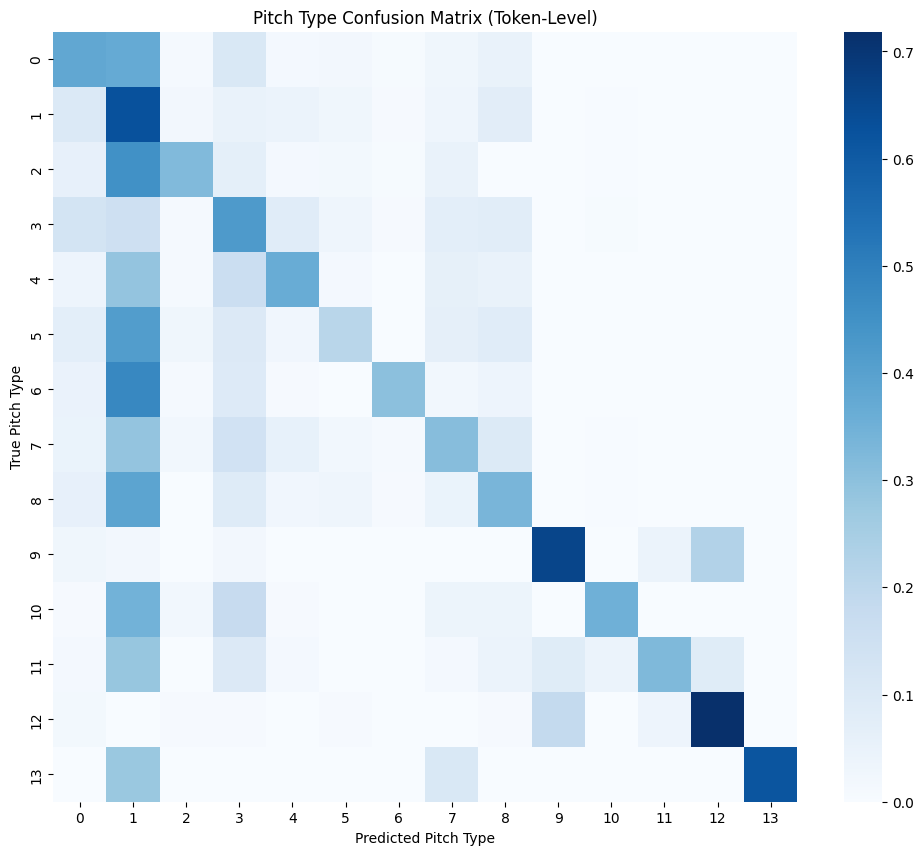

In [33]:
early_stopping_results = evaluate_model_complete(
    model=early_stopping_model,
    test_loader=test_loader,
    device=device,
    id_to_pitch=id_to_pitch,
    num_classes=num_classes,
    pad_id=PAD_ID
)


1. Token Accuracy:
Token Accuracy (no PAD): 42.96%

2. Top-3 Accuracy:
Top-3 Accuracy: 87.73%

3. Most Common Predictions:
Top 5 most predicted pitches:
  FF: 138525
  SI: 44324
  CH: 17004
  SL: 15621
  ST: 14223

4. Detailed Classification Report:
              precision    recall  f1-score   support

          SL       0.47      0.35      0.40     15820
          FF       0.50      0.49      0.49     33475
          FS       0.39      0.56      0.46      3889
          SI       0.43      0.46      0.44     15342
          ST       0.37      0.49      0.42      7596
          CU       0.38      0.20      0.26      7114
          KC       0.31      0.65      0.42      1781
          FC       0.35      0.32      0.33      7658
          CH       0.37      0.41      0.39     12150
          FA       0.75      0.84      0.79       142
          SV       0.28      0.53      0.37       530
       OTHER       0.20      0.34      0.25        71
          EP       0.77      0.70      0.73   

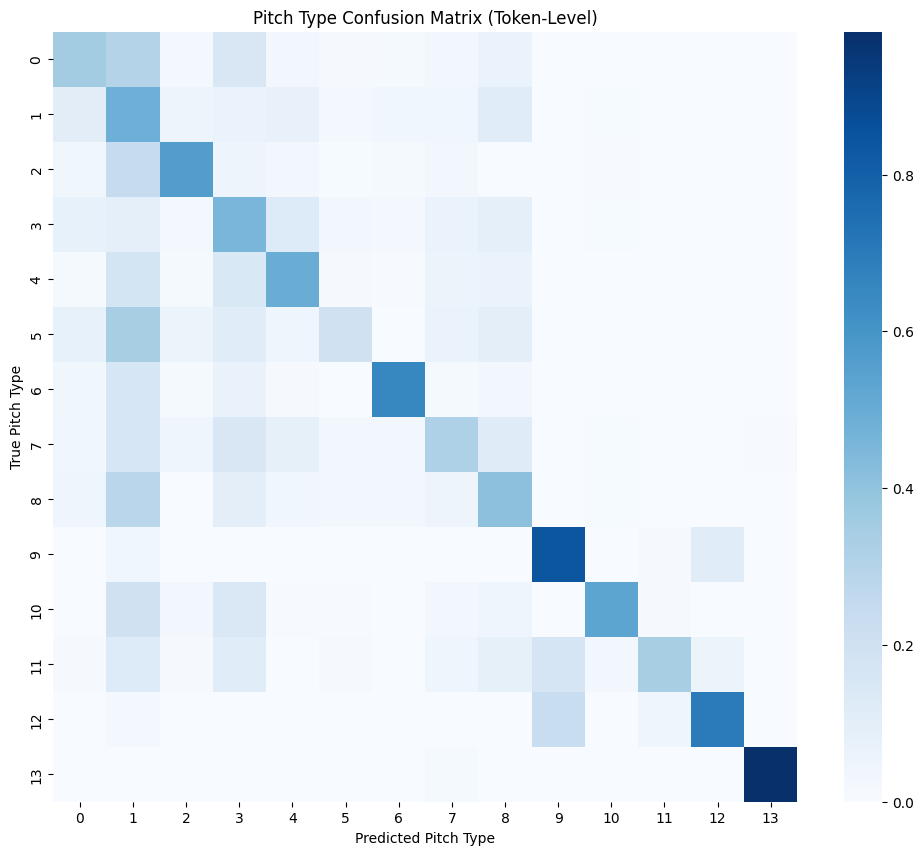

In [34]:
dropout_results = evaluate_model_complete(
    model=dropout_model,
    test_loader=test_loader,
    device=device,
    id_to_pitch=id_to_pitch,
    num_classes=num_classes,
    pad_id=PAD_ID
)


1. Token Accuracy:
Token Accuracy (no PAD): 42.43%

2. Top-3 Accuracy:
Top-3 Accuracy: 87.55%

3. Most Common Predictions:
Top 5 most predicted pitches:
  FF: 104531
  SI: 80098
  SL: 25403
  CH: 18035
  FC: 8909

4. Detailed Classification Report:
              precision    recall  f1-score   support

          SL       0.42      0.44      0.43     15820
          FF       0.51      0.45      0.48     33475
          FS       0.39      0.50      0.44      3889
          SI       0.42      0.49      0.45     15342
          ST       0.40      0.34      0.37      7596
          CU       0.33      0.24      0.28      7114
          KC       0.37      0.38      0.38      1781
          FC       0.35      0.31      0.33      7658
          CH       0.36      0.43      0.39     12150
          FA       0.81      0.73      0.77       142
          SV       0.29      0.57      0.39       530
       OTHER       0.34      0.41      0.37        71
          EP       0.72      0.74      0.73    

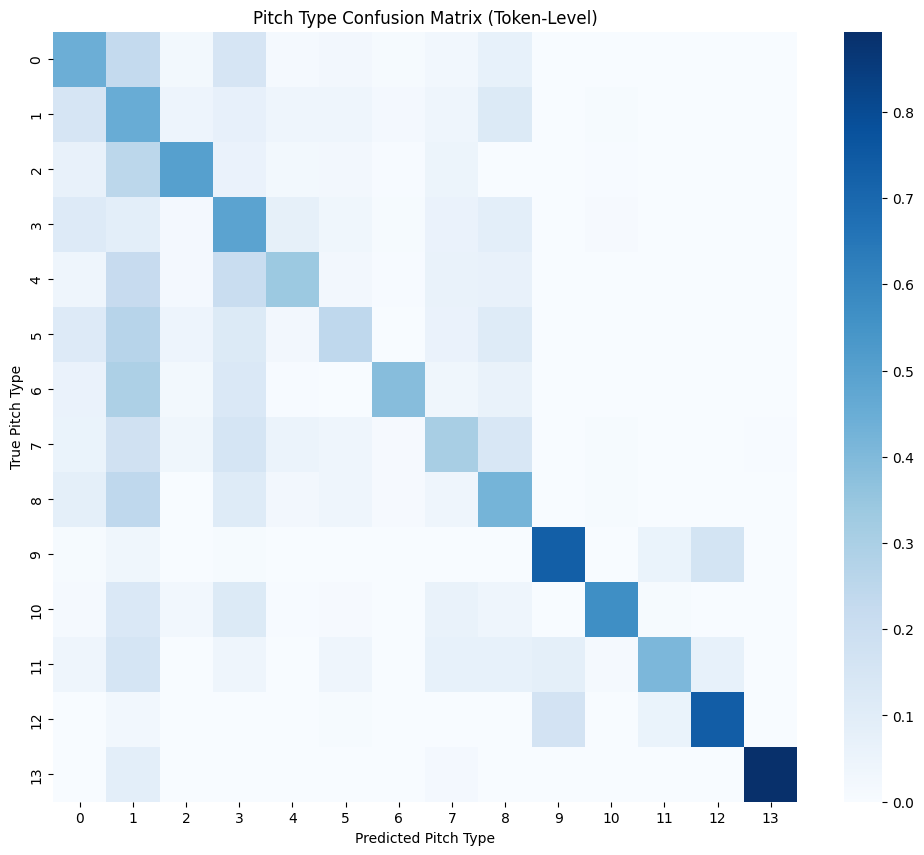

In [35]:
emb_results = evaluate_model_complete(
    model=emb_model,
    test_loader=test_loader,
    device=device,
    id_to_pitch=id_to_pitch,
    num_classes=num_classes,
    pad_id=PAD_ID
)

In [36]:
# out_dir = Path.cwd() / "trained-parameters"
# out_dir.mkdir(parents=True, exist_ok=True)
# filename = f"simple_rnn_v0_1_{datetime.now().strftime('%Y%m%d')}.pt"
# save_path = out_dir / filename
# torch.save(model.state_dict(), save_path)
# print(f"Wrote model parameters to {save_path}")